# Emotion Recognition

# 1. Import Libraries and Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import zipfile
import os
import warnings
warnings.filterwarnings('ignore')
# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical

# 2. Load and Explore Dataset

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# extract the zip file from the drive
zip_path = '/content/drive/MyDrive/FER.zip'
extract_path = '/content/FER'

if not os.path.exists(extract_path):
  with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [ ]:
os.listdir('/content/FER')

['train', 'test']

In [ ]:
# define directory paths for train and test
train_dir = os.path.join(extract_path, "train")
test_dir = os.path.join(extract_path, "test")

In [ ]:
print("Train Data: ",os.listdir(train_dir))
print("Test Data: ",os.listdir(test_dir))

Train Data:  ['neutral', 'surprise', 'disgust', 'sad', 'angry', 'fear', 'happy']
Test Data:  ['neutral', 'surprise', 'disgust', 'sad', 'angry', 'fear', 'happy']


In [ ]:
# mapping the emotions to numerical labels
emotion_mapping = {
    "fear": 0, "neutral": 1, "sad": 2, "angry": 3,
    "happy": 4, "disgust": 5, "surprise": 6
}

In [ ]:
# Load images and labels
from PIL import Image
def load_images(directory):
  images = []
  labels = []
  for emotion in os.listdir(directory): # loop through each emotion directory
    emotion_dir = os.path.join(directory, emotion)
    if os.path.isdir(emotion_dir):
      for img_file in os.listdir(emotion_dir): # loop through each image directory
        img_path = os.path.join(emotion_dir, img_file)
        try:
          img = Image.open(img_path).convert("L") # coverts to grayscale
          img = img.resize((48,48)) # resize to 48 x 48
          images.append(np.array(img))
          labels.append(emotion_mapping[emotion])
        except Exception as e:
          print(f"Error loading image {img_path}: {e}")
  return np.array(images), np.array(labels)


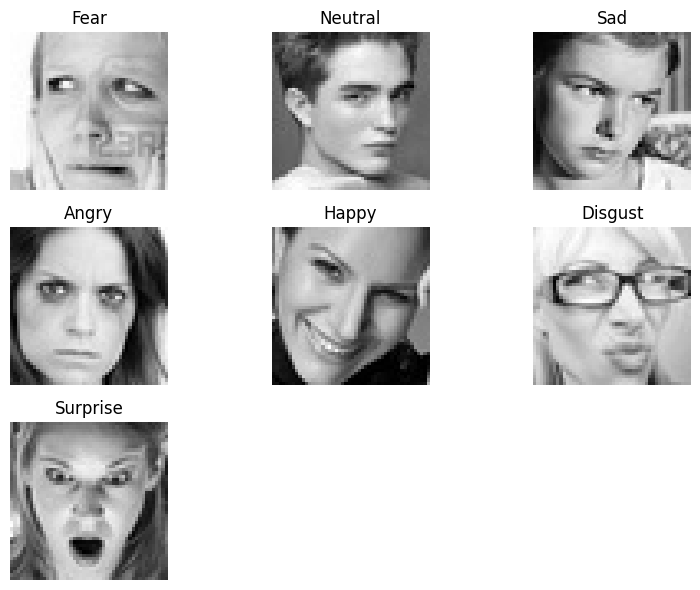

In [ ]:
# visualize one image from each emotions
def visualize_image(directory):
  plt.figure(figsize =(8,6))
  for i, emotion in enumerate(emotion_mapping.keys()):
    emotion_dir = os.path.join(directory, emotion)
    image_path = os.path.join(emotion_dir, os.listdir(emotion_dir)[0])
    img = Image.open(image_path).convert("L")
    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap="grey")
    plt.title(emotion.capitalize())
    plt.axis('off')
  plt.tight_layout()
  plt.show()
visualize_image(train_dir)

# 3.Data Preprocessing

gsdfgdfgsd

In [ ]:
# Load Train and Test Data
X_train, y_train = load_images(train_dir)
X_test, y_test = load_images(test_dir)

In [ ]:
# Normalize pixel values
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
# Add a channel dimension
X_train = X_train.reshape(-1, 48, 48, 1)
X_test = X_test.reshape(-1, 48, 48, 1)

In [ ]:
# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=7)
y_test = to_categorical(y_test, num_classes=7)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)


# 4. Exploratory Data Analysis (EDA)

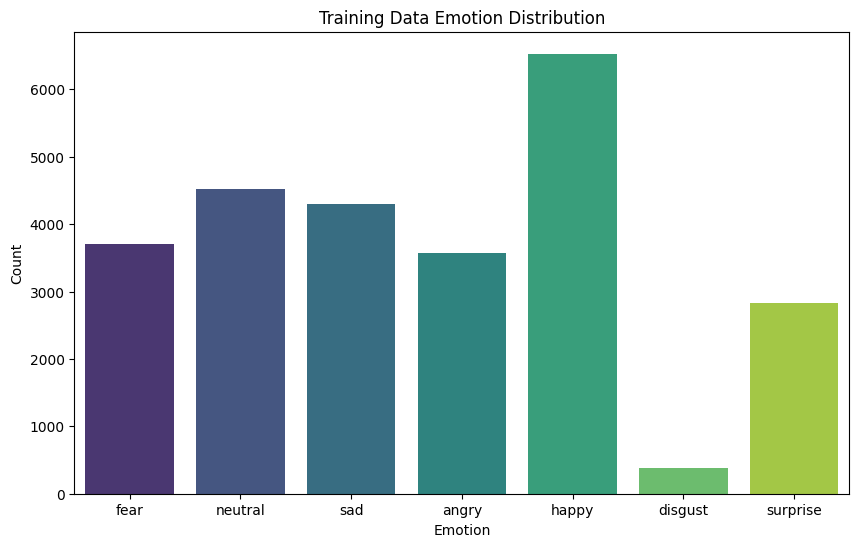

In [ ]:
emotion_counts = np.argmax(y_train, axis=1)
plt.figure(figsize=(10, 6))
sns.countplot(x=emotion_counts, palette="viridis")
plt.title("Training Data Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(ticks=range(7), labels=list(emotion_mapping.keys()))
plt.show()

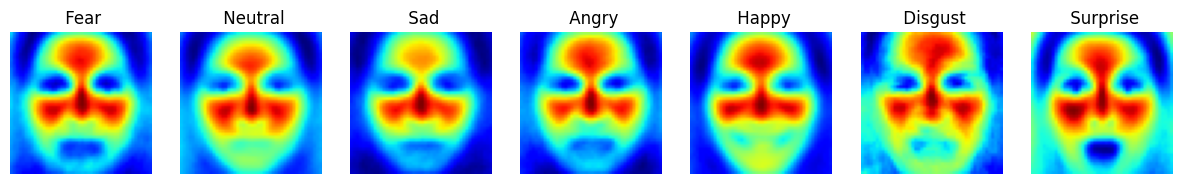

In [ ]:
# The viusal grid (Mean Image Shadow) - classic Profiles
plt.figure(figsize=(15, 5))
for i, (emotion, label) in enumerate(emotion_mapping.items()):
    # Filter all images of this specific emotion
    indices = np.where(np.argmax(y_train, axis=1) == label)[0]
    # Calculate the average pixel value for this class
    mean_img = np.mean(X_train[indices], axis=0).reshape(48, 48)

    plt.subplot(1, 7, i+1)
    plt.imshow(mean_img, cmap='jet') # Using 'jet' highlights intensity differences
    plt.title(f" {emotion.capitalize()}")
    plt.axis('off')
plt.show()

# 5. Model Buildind - CNN

In [ ]:
#CNN Model Architecture
def build_cnn_model(input_shape=(48, 48, 1)):
    model = Sequential([
        # CNN Bloack 1
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        #CNN Block 2
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        #CNN Block 3
        Conv2D(128, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),
        # Flatten and Dense layers
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        # Output layer for 7 emotions
        Dense(7, activation='softmax')
    ])
    return model

In [ ]:
#compile the model
cnn_model = build_cnn_model()
cnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Train the model
history = cnn_model.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_val, y_val), verbose=1)


Epoch 1/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 88s 210ms/step - accuracy: 0.2776 - loss: 2.0783 - val_accuracy: 0.2424 - val_loss: 2.2778
Epoch 2/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 81s 200ms/step - accuracy: 0.3986 - loss: 1.5795 - val_accuracy: 0.4082 - val_loss: 1.5296
Epoch 3/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 82s 203ms/step - accuracy: 0.4567 - loss: 1.4265 - val_accuracy: 0.3974 - val_loss: 1.5456
Epoch 4/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 143s 207ms/step - accuracy: 0.4830 - loss: 1.3623 - val_accuracy: 0.4800 - val_loss: 1.3389
Epoch 5/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 144s 210ms/step - accuracy: 0.5014 - loss: 1.3086 - val_accuracy: 0.5207 - val_loss: 1.2579
Epoch 6/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 85s 210ms/step - accuracy: 0.5144 - loss: 1.2716 - val_accuracy: 0.4970 - val_loss: 1.3070
Epoch 7/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 84s 208ms/step - accuracy: 0.5245 - loss: 1.2535 - val_accuracy: 0.5124 - val_loss: 1.2615
Epoch 8/30
404/404 ━━━━━━━━━━━━━━━━━━━━ 141s 205ms/step - accuracy: 0.5396 - loss

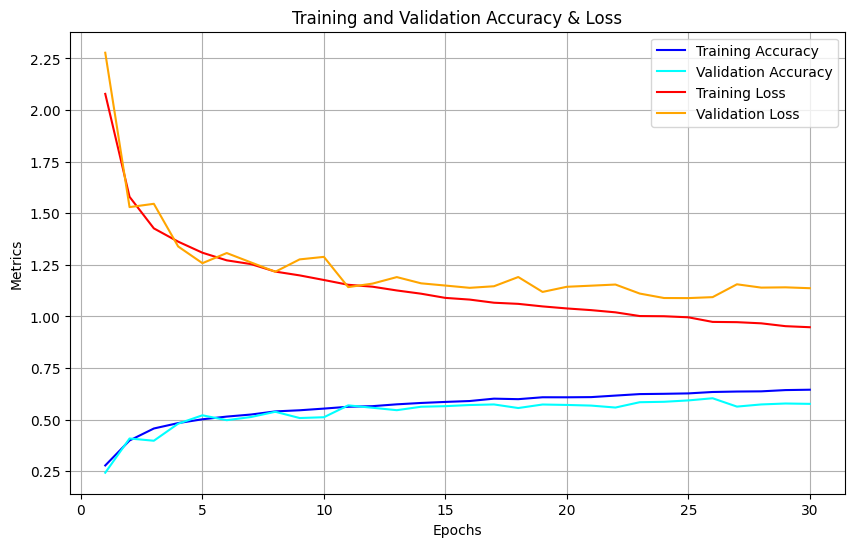

In [ ]:
# Plot accuracy and loss
def plot_training_history(history):
    epochs = range(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(10, 6))
    # Plot training and validation accuracy
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='blue')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', color='cyan')

    # Plot training and validation loss
    plt.plot(epochs, history.history['loss'], label='Training Loss', color='red')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss', color='orange')

    plt.title('Training and Validation Accuracy & Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Metrics')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(history)


# 6. Evaluate the Model

In [ ]:
# Evaluate Model
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5975 - loss: 1.0912
Test Loss: 1.0912, Test Accuracy: 0.5975


In [ ]:
# Confusion Matrix
y_pred = np.argmax(cnn_model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)
conf_matrix = confusion_matrix(y_true, y_pred)

225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step


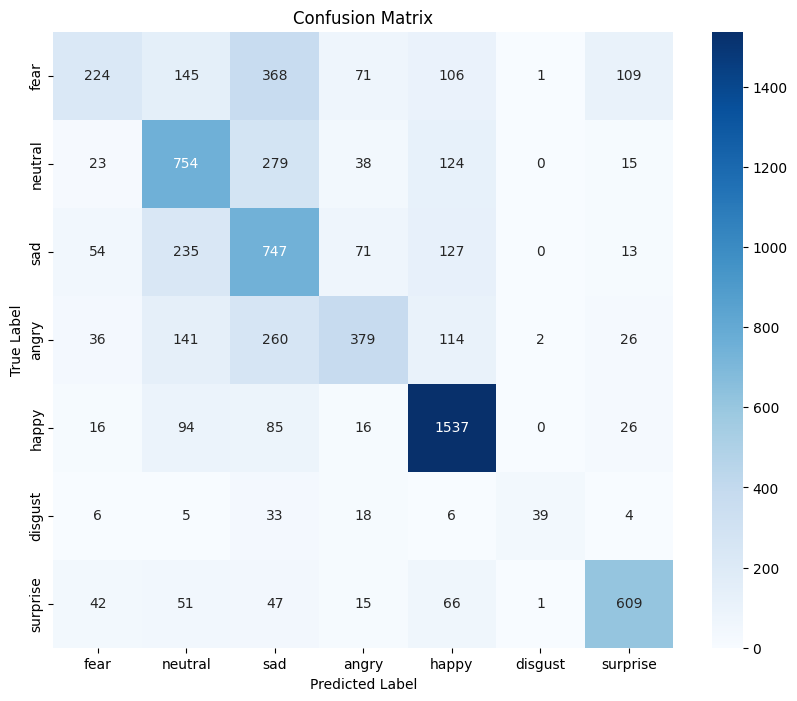

In [ ]:
# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=list(emotion_mapping.keys()), yticklabels=list(emotion_mapping.keys()))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step


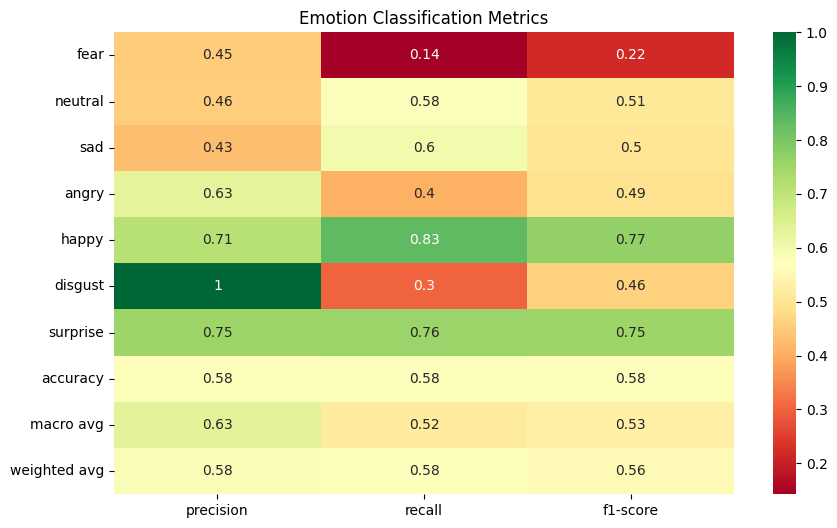

In [ ]:


# 1. Get predictions
y_pred = cnn_model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_val, axis=1)

# 2. Create report
report = classification_report(y_true, y_pred_classes,
                               target_names=list(emotion_mapping.keys()),
                               output_dict=True)

# 3. Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True, cmap='RdYlGn')
plt.title('Emotion Classification Metrics')
plt.show()

In [ ]:
cnn_model.save('emotion_model.h5')

In [ ]:
from google.colab import files
files.download('emotion_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>